<style>
:root { --text:#1f2937; --muted:#5b6472; --line:#d7dde6; --soft:#f6f8fb; --accent:#274060; }
body { color: var(--text); line-height: 1.55; }
.jp-Notebook, .notebook-container { max-width: 1120px; margin: 0 auto; }
h1 { border-bottom: 2px solid var(--accent); padding-bottom: .25em; }
h2 { margin-top: 1.9em; border-bottom: 1px solid var(--line); padding-bottom: .2em; }
h3 { margin-top: 1.4em; }
table { border-collapse: collapse; margin-top: .5em; margin-bottom: 1em; }
th, td { border: 1px solid var(--line); padding: 6px 10px; vertical-align: top; }
th { background: var(--soft); }
code { font-size: 0.95em; }
blockquote { border-left: 4px solid var(--line); padding-left: 1em; color: var(--muted); }
</style>
# Z02. Tokenizacja, normalizacja i porównanie korpusów

Materiały:

- `anna_karenina.txt` — angielski przekład *Anna Karenina* autorstwa Constance Garnett,
- `jane_eyre.txt` — *Jane Eyre* Charlotte Brontë w języku angielskim.

Celem jest porównanie dwóch korpusów przy użyciu metod omawianych na W02. Różnic między tekstami nie należy automatycznie przypisywać autorom: *Anna Karenina* jest analizowana w przekładzie.

Wnioski powinny rozróżniać wynik obliczeń, interpretację oraz ograniczenia przyjętej reprezentacji i danych.


In [1]:
from pathlib import Path
from collections import Counter
import re
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from IPython.display import display

# Pobieranie jest potrzebne tylko przy pierwszym uruchomieniu.
resources = {
    "punkt_tab": "tokenizers/punkt_tab/english/",
    "stopwords": "corpora/stopwords",
    "wordnet": "corpora/wordnet.zip",
    "omw-1.4": "corpora/omw-1.4.zip",
    "averaged_perceptron_tagger_eng": "taggers/averaged_perceptron_tagger_eng/",
}
for resource, location in resources.items():
    try:
        nltk.data.find(location)
    except LookupError:
        if not nltk.download(resource, quiet=True):
            raise RuntimeError(f"Nie udało się pobrać zasobu NLTK: {resource}")

from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk import pos_tag
from nltk.util import ngrams

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 150)
plt.rcParams.update({"figure.figsize": (10, 5), "axes.grid": True, "grid.alpha": 0.25})
print(f"Python {sys.version.split()[0]}, NLTK {nltk.__version__}, pandas {pd.__version__}, NumPy {np.__version__}")


Python 3.12.0, NLTK 3.9.2, pandas 2.3.3, NumPy 2.3.3


## 1. Wczytanie i oczyszczenie korpusów

Pliki Project Gutenberg zawierają nagłówki i informacje licencyjne poza właściwym tekstem. Napisz funkcję `strip_gutenberg(text)`, która zachowa część między znacznikami początku i końca e-booka.

Po oczyszczeniu wyświetl pierwsze i ostatnie 300 znaków obu tekstów. Sprawdź, czy metadane zostały usunięte.

In [2]:
def read_text(path):
    return Path(path).read_text(encoding="utf-8-sig")


def strip_gutenberg(text):
    start = re.search(r"^\*\*\*\s*START OF (?:THE|THIS) PROJECT GUTENBERG EBOOK[^\n]*\*\*\*\s*$", text, re.MULTILINE)
    end = re.search(r"^\*\*\*\s*END OF (?:THE|THIS) PROJECT GUTENBERG EBOOK[^\n]*\*\*\*\s*$", text, re.MULTILINE)
    if start is None or end is None or end.start() <= start.end():
        raise ValueError("Brak poprawnej pary znaczników początku i końca e-booka.")
    return text[start.end():end.start()].strip()


corpora = {
    "Anna Karenina": strip_gutenberg(read_text("anna_karenina.txt")),
    "Jane Eyre": strip_gutenberg(read_text("jane_eyre.txt")),
}
for name, text in corpora.items():
    print(f"\n{name} — początek:\n{text[:300]}")
    print(f"\n{name} — koniec:\n{text[-300:]}")
    assert "*** START OF" not in text and "*** END OF" not in text
    assert "END OF THE PROJECT GUTENBERG LICENSE" not in text

example = "nagłówek\n*** START OF THE PROJECT GUTENBERG EBOOK TEST ***\ntreść\n*** END OF THE PROJECT GUTENBERG EBOOK TEST ***\nlicencja"
assert strip_gutenberg(example) == "treść"
try:
    strip_gutenberg("tekst bez znaczników")
except ValueError:
    pass
else:
    raise AssertionError("Brak znaczników powinien zgłosić błąd.")



Anna Karenina — początek:
[Illustration]




 ANNA KARENINA 

 by Leo Tolstoy 

 Translated by Constance Garnett 

Contents


 PART ONE
 PART TWO
 PART THREE
 PART FOUR
 PART FIVE
 PART SIX
 PART SEVEN
 PART EIGHT




PART ONE

Chapter 1


Happy families are all alike; every unhappy family is unhappy in its
own way.

Everyth

Anna Karenina — koniec:
unable to understand with my reason why I pray, and I shall
still go on praying; but my life now, my whole life apart from anything
that can happen to me, every minute of it is no more meaningless, as it
was before, but it has the positive meaning of goodness, which I have
the power to put into it.”

Jane Eyre — początek:
JANE EYRE
AN AUTOBIOGRAPHY

by Charlotte Brontë

_ILLUSTRATED BY F. H. TOWNSEND_

London
SERVICE & PATON
5 HENRIETTA STREET
1897

_The Illustrations_
_in this Volume are the copyright of_
SERVICE & PATON, _London_

TO
W. M. THACKERAY, ESQ.,

This Work
IS RESPECTFULLY INSCRIBED

BY
THE AUTHOR




PRE

Jane Eyre — koniec:
i

Usunięto zewnętrzne nagłówki i końcową licencję Project Gutenberg. W obszarze między znacznikami pozostają elementy wydania: tytuły, spis treści, podpisy ilustracji, a w *Jane Eyre* również przedmowa i dedykacja. Zachowuje całą zawartość między znacznikami; nie jest ona wyłącznie tekstem narracji.


## 2. Jednostki tekstu i porównywalność miar

Dla każdego korpusu policz:

- liczbę znaków,
- liczbę zdań według `sent_tokenize`,
- liczbę wszystkich tokenów według `word_tokenize`,
- liczbę tokenów słownych,
- średnią i medianę liczby tokenów słownych w zdaniu.

Za token słowny przyjmij na tym etapie token spełniający `isalpha()`.

Zapisz wyniki w jednej tabeli. W interpretacji wskaż, które miary zależą bezpośrednio od długości korpusu, a które są już częściowo znormalizowane.

In [3]:
# Ujednolicamy apostrofy przed tokenizacją obu książek.
# NLTK rozpoznaje wtedy don't jako do + n't, także gdy oryginał zawiera don’t.
def normalize_apostrophes(text):
    return text.translate(str.maketrans({"’": "'", "‘": "'"}))


sentences = {}
sentence_tokens = {}
all_tokens = {}
word_tokens = {}
lower_words = {}
rows = []
for name, text in corpora.items():
    sentences[name] = sent_tokenize(normalize_apostrophes(text), language="english")
    # Zdania już są wyznaczone; preserve_line zapobiega ponownej segmentacji.
    sentence_tokens[name] = [word_tokenize(s, language="english", preserve_line=True) for s in sentences[name]]
    all_tokens[name] = [t for sentence in sentence_tokens[name] for t in sentence]
    word_tokens[name] = [t for t in all_tokens[name] if t.isalpha()]
    lower_words[name] = [t.lower() for t in word_tokens[name]]
    lengths = [sum(t.isalpha() for t in sentence) for sentence in sentence_tokens[name]]
    rows.append({
        "korpus": name,
        "znaki": len(text),
        "zdania": len(sentences[name]),
        "wszystkie_tokeny": len(all_tokens[name]),
        "tokeny_słowne": len(word_tokens[name]),
        "średnia_słów_w_zdaniu": np.mean(lengths),
        "mediana_słów_w_zdaniu": np.median(lengths),
    })
summary = pd.DataFrame(rows).set_index("korpus")
assert "n't" in word_tokenize(normalize_apostrophes("I don’t agree."), preserve_line=True)
display(summary.round(2))


,znaki,zdania,wszystkie_tokeny,tokeny_słowne,średnia_słów_w_zdaniu,mediana_słów_w_zdaniu
korpus,,,,,,
Anna Karenina,1964766,16853,423711,344695,20.45,17.0
Jane Eyre,1022379,6898,223672,179837,26.07,21.0


Interpretacja: liczby znaków, zdań i tokenów bezpośrednio zależą od długości korpusu. Średnia i mediana liczby słów w zdaniu są częściowo znormalizowane, lecz zależą od segmentacji zdań, dialogów i struktury utworu. Liczymy także zdania, które po filtrze `isalpha()` nie zawierają słów.

Liczba znaków dotyczy tekstu po usunięciu otoczki Gutenberga. Przed tokenizacją w obu książkach zamieniamy apostrofy typograficzne na ASCII; wyniki odnoszą się do tej jawnej procedury. `isalpha()` usuwa liczby, interpunkcję i tokeny zawierające łączniki lub apostrofy. W wariantach A/B odpada także `n't`, natomiast fragmenty kontrakcji, np. `ca` z `can't`, mogą pozostać jako tokeny słowne.


## 3. Wpływ normalizacji na słownik i częstości

Dla każdego korpusu przygotuj trzy warianty:

A. tokeny słowne bez zmiany wielkości liter,  
B. tokeny słowne po `lower()`,  
C. wariant B po usunięciu słów stop, ale z zachowaniem `no`, `nor`, `not` oraz normalizacją `n't → not`.

Dla każdego wariantu:

- policz liczbę tokenów i typów,
- pokaż 15 najczęstszych typów,
- policz częstość względną 15 najczęstszych typów,
- policz zmianę rozmiaru słownika względem wariantu A.

W komentarzu oddziel zmiany techniczne od takich, które mogą zmieniać interpretację tekstu.

In [4]:
english_stopwords = set(stopwords.words("english"))
negations = {"no", "nor", "not"}
stopwords_without_negation = english_stopwords - negations


def lexical_with_negation(tokens):
    # Mapowanie musi poprzedzać isalpha(), inaczej n't zostałoby utracone.
    normalized = ["not" if t.lower() == "n't" else t.lower() for t in tokens]
    return [t for t in normalized if t.isalpha()]


def content_tokens(tokens):
    return [t for t in lexical_with_negation(tokens) if t not in stopwords_without_negation]


variants = {}
normalization_rows = []
normalization_top_rows = []
for name in corpora:
    variants[name] = {
        "A": word_tokens[name],
        "B": lower_words[name],
        "C": content_tokens(all_tokens[name]),
    }
    baseline = len(set(variants[name]["A"]))
    for variant, tokens in variants[name].items():
        counts = Counter(tokens)
        normalization_rows.append({
            "korpus": name, "wariant": variant,
            "tokeny": len(tokens), "typy": len(counts),
            "zmiana_typów_względem_A": len(counts) - baseline,
            "zmiana_%_względem_A": 100 * (len(counts) / baseline - 1),
        })
        for token, count in counts.most_common(15):
            normalization_top_rows.append({"korpus": name, "wariant": variant,
                "typ": token, "liczba": count, "częstość_względna": count / len(tokens)})
normalization_summary = pd.DataFrame(normalization_rows)
normalization_top = pd.DataFrame(normalization_top_rows)
display(normalization_summary.round(3))
for (name, variant), table in normalization_top.groupby(["korpus", "wariant"], sort=False):
    print(f"{name} — wariant {variant}")
    display(table[["typ", "liczba", "częstość_względna"]].reset_index(drop=True).round(6))
assert content_tokens(word_tokenize("No, I don't agree, nor do I accept it.", preserve_line=True)).count("not") == 1
assert negations <= set(content_tokens(["no", "nor", "not", "the"]))


,korpus,wariant,tokeny,typy,zmiana_typów_względem_A,zmiana_%_względem_A
0,Anna Karenina,A,344695,13141,0,0.000
1,Anna Karenina,B,344695,12277,-864,-6.575
2,Anna Karenina,C,162011,12149,-992,-7.549
3,Jane Eyre,A,179837,12947,0,0.000
4,Jane Eyre,B,179837,12124,-823,-6.357
5,Jane Eyre,C,84614,11996,-951,-7.345


Anna Karenina — wariant A


,typ,liczba,częstość_względna
0,the,16367,0.047483
1,and,11749,0.034085
2,to,9996,0.029000
3,of,8537,0.024767
4,he,6462,0.018747
5,a,5949,0.017259
6,in,5654,0.016403
7,was,5302,0.015382
8,that,5187,0.015048
9,his,5079,0.014735


Anna Karenina — wariant B


,typ,liczba,częstość_względna
0,the,17505,0.050784
1,and,12843,0.037259
2,to,10115,0.029345
3,of,8603,0.024958
4,he,7779,0.022568
5,a,6116,0.017743
6,in,5927,0.017195
7,that,5444,0.015794
8,was,5318,0.015428
9,his,5226,0.015161


...

,typ,liczba,częstość_względna
0,the,7328,0.040748
1,I,7089,0.039419
2,and,6260,0.034809
3,to,5029,0.027964
4,of,4310,0.023966
5,a,4218,0.023455
6,in,2649,0.014730
7,you,2548,0.014168
8,was,2490,0.013846
9,my,2049,0.011394


Jane Eyre — wariant B


,typ,liczba,częstość_względna
0,the,7766,0.043184
1,i,7096,0.039458
2,and,6541,0.036372
3,to,5093,0.028320
4,a,4373,0.024316
5,of,4345,0.024161
6,you,2873,0.015976
7,in,2736,0.015214
8,was,2503,0.013918
9,it,2304,0.012812


Jane Eyre — wariant C


,typ,liczba,częstość_względna
0,not,1863,0.022018
1,no,707,0.008356
2,would,664,0.007847
3,one,575,0.006796
4,said,557,0.006583
5,could,502,0.005933
6,like,359,0.004243
7,rochester,358,0.004231
8,little,338,0.003995
9,jane,311,0.003676


Zmiany techniczne: `lower()` scala warianty różniące się wielkością liter, a usunięcie słów stop zmniejsza liczbę tokenów i zmienia mianownik częstości względnej. Zmiany interpretacyjne: tracimy rozróżnienie części nazw własnych i wyrazów pospolitych oraz wiele informacji gramatycznych. Zachowanie `no`, `nor`, `not` ogranicza utratę negacji, ale nie odtwarza jej zakresu ani znaczenia całego zdania.

Wariant C powstaje z tokenów źródłowych przez `lower()`, zamianę `n't → not`, filtr `isalpha()` i usunięcie słów stop. Nie można zbudować go wyłącznie z gotowego B, ponieważ B już usunął `n't`. Liczba zachowanych negacji jest miarą tokenową: np. `not only` i `no` nie muszą oznaczać negatywnego nastawienia.


## 4. Stemming i lematyzacja

Dla pierwszych 20 000 tokenów słownych każdego korpusu porównaj:

- formy po `lower()`,
- stemmy z `PorterStemmer`,
- lematy wyznaczone przy użyciu `WordNetLemmatizer`.

W pomocniczej funkcji poniżej automatyczny tag części mowy służy jedynie do poprawnego przekazania kategorii do lematyzatora. Tagowanie części mowy będzie omawiane dokładniej na W03.

In [5]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()


def penn_to_wordnet(tag):
    if tag.startswith("J"):
        return wordnet.ADJ
    if tag.startswith("V"):
        return wordnet.VERB
    if tag.startswith("N"):
        return wordnet.NOUN
    if tag.startswith("R"):
        return wordnet.ADV
    return None


def lemmatize_tokens(tokens):
    tagged = pos_tag(tokens)
    result = []
    for token, tag in tagged:
        wn_tag = penn_to_wordnet(tag)
        if wn_tag is None:
            result.append(token.lower())
        else:
            result.append(lemmatizer.lemmatize(token.lower(), pos=wn_tag))
    return result



representations = {}
morphology_rows = []
for name in corpora:
    sample = word_tokens[name][:20000]
    representations[name] = {
        "lower": [t.lower() for t in sample],
        "stem": [stemmer.stem(t.lower()) for t in sample],
        # Przekazujemy oryginalną wielkość liter do taggera.
        "lemma": lemmatize_tokens(sample),
    }
    baseline = len(set(representations[name]["lower"]))
    for representation, values in representations[name].items():
        morphology_rows.append({"korpus": name, "reprezentacja": representation,
            "tokeny": len(values), "typy": len(set(values)),
            "redukcja_%_względem_lower": 100 * (1 - len(set(values)) / baseline)})
morphology_summary = pd.DataFrame(morphology_rows)
display(morphology_summary.round(2))

# Kandydaci pochodzą z analizowanych fragmentów, a nie z gotowej listy przykładów.
# Szukamy lematów słownikowych i uciętych stemów nieobecnych w WordNet.
morphology_candidates = {}
for name, values in representations.items():
    triples = Counter(zip(values["lower"], values["stem"], values["lemma"]))
    candidates = []
    used_stems = set()
    for (token, stem, lemma), count in triples.most_common():
        if (stem != lemma and len(stem) >= 4 and len(lemma) >= 6
                and lemma.startswith(stem) and stem not in used_stems
                and wordnet.synsets(lemma) and not wordnet.synsets(stem)):
            candidates.append({"forma": token, "stem": stem, "lemat": lemma, "liczba_w_próbce": count})
            used_stems.add(stem)
        if len(candidates) == 5:
            break
    assert len(candidates) == 5
    morphology_candidates[name] = pd.DataFrame(candidates)
    print(name, "— pięć przykładów")
    display(morphology_candidates[name])


,korpus,reprezentacja,tokeny,typy,redukcja_%_względem_lower
0,Anna Karenina,lower,20000,2894,0.00
1,Anna Karenina,stem,20000,2299,20.56
2,Anna Karenina,lemma,20000,2424,16.24
3,Jane Eyre,lower,20000,3856,0.00
4,Jane Eyre,stem,20000,3048,20.95
5,Jane Eyre,lemma,20000,3227,16.31


Anna Karenina — pięć przykładów


,forma,stem,lemat,liczba_w_próbce
0,nothing,noth,nothing,31
1,little,littl,little,27
2,always,alway,always,21
3,another,anoth,another,20
4,people,peopl,people,18


Jane Eyre — pięć przykładów


,forma,stem,lemat,liczba_w_próbce
0,little,littl,little,54
1,before,befor,before,43
2,always,alway,always,15
3,nothing,noth,nothing,14
4,strange,strang,strange,13


Policz liczbę unikalnych wartości w każdej reprezentacji i procentową redukcję słownika.

Znajdź po pięć przykładów, dla których stem jest wyraźnie mniej interpretowalny niż lemat. Nie używaj przykładów z wykładu.

Krótko oceń, czy większa redukcja liczby typów musi oznaczać lepszą reprezentację.

Większa redukcja liczby typów nie musi oznaczać lepszej reprezentacji: stemming może scalać słowa o różnych znaczeniach i tworzyć formy trudne do odczytania. W tabelach powyżej stem jest uciętym fragmentem bez hasła w WordNet, podczas gdy lemat ma postać słownikową; to pomocnicze kryterium wyboru, a nie definicja poprawności językowej. Lematyzacja zależy od jakości automatycznego tagowania i zasobów WordNet; filtr słów usuwa część kontekstu przed tagowaniem. Redukcję liczymy względem `lower()` na tych samych 20 000 pozycjach.


## 5. Częstości względne i rozkład rang

Dla każdego korpusu użyj tej samej procedury przygotowania tokenów: `lower()`, tokeny słowne, bez usuwania słów stop.

1. Policz 30 najczęstszych typów.
2. Podaj ich częstości na 10 000 tokenów.
3. Dla wszystkich typów uporządkowanych według częstości utwórz wykres:
   - oś X: ranga,
   - oś Y: częstość,
   - obie osie w skali logarytmicznej.
4. Porównaj kształt wykresów dla obu korpusów.

Nie oczekuj idealnej linii prostej. Prawo Zipfa jest empirycznym przybliżeniem rozkładu częstości.

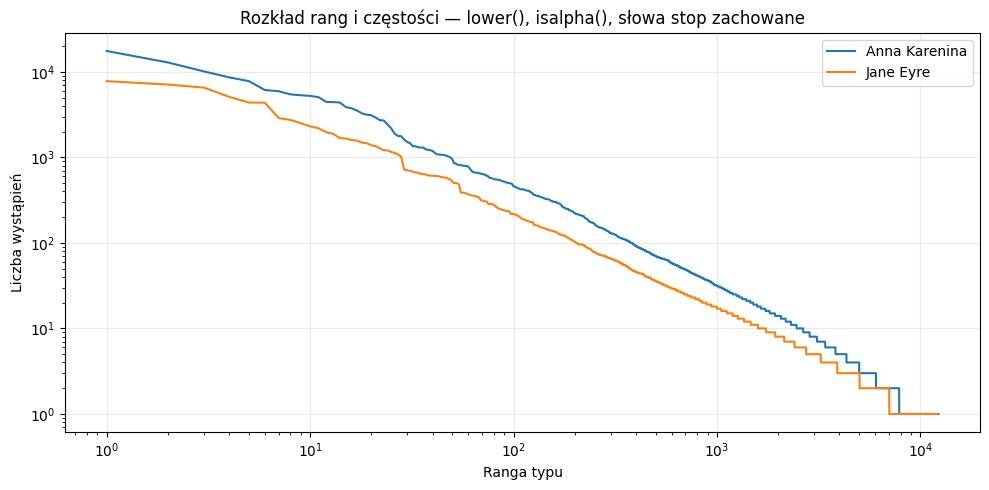

Anna Karenina


,typ,liczba,na_10000_tokenów
0,the,17505,507.840
1,and,12843,372.590
2,to,10115,293.448
3,of,8603,249.583
4,he,7779,225.678
5,a,6116,177.432
6,in,5927,171.949
7,that,5444,157.937
8,was,5318,154.281
9,his,5226,151.612


Jane Eyre


,typ,liczba,na_10000_tokenów
0,the,7766,431.835
1,i,7096,394.580
2,and,6541,363.718
3,to,5093,283.201
4,a,4373,243.165
5,of,4345,241.608
6,you,2873,159.756
7,in,2736,152.138
8,was,2503,139.182
9,it,2304,128.116


In [6]:
frequency_counts = {name: Counter(tokens) for name, tokens in lower_words.items()}
top30_rows = []
fig, ax = plt.subplots()
for name, counts in frequency_counts.items():
    total = len(lower_words[name])
    for token, count in counts.most_common(30):
        top30_rows.append({"korpus": name, "typ": token, "liczba": count, "na_10000_tokenów": count / total * 10000})
    frequencies = np.array(sorted(counts.values(), reverse=True))
    ax.loglog(np.arange(1, len(frequencies) + 1), frequencies, label=name)
ax.set(xlabel="Ranga typu", ylabel="Liczba wystąpień", title="Rozkład rang i częstości — lower(), isalpha(), słowa stop zachowane")
ax.legend()
plt.tight_layout()
plt.show()
top30 = pd.DataFrame(top30_rows)
for name in corpora:
    print(name)
    display(top30[top30["korpus"] == name].drop(columns="korpus").reset_index(drop=True).round(3))


Interpretacja: oba rozkłady mają malejącą część centralną i długi ogon rzadkich typów; w ogonie występują schodki wynikające z całkowitych liczebności(remisów dla tych samych slow). Zbliżony do liniowego przebieg części wykresu log–log jest zgodny z przybliżeniem Zipfa, lecz nie dowodzi ścisłego prawa potęgowego. Oś Y pokazuje liczby wystąpień, więc przesunięcie krzywych zależy także od długości książek; do porównania częstości poszczególnych słów służą tabele na 10 000 tokenów. Nie dopasowujemy prawa Zipfa ani nie zakładamy idealnej prostej.


## 6. Wzrost słownika, TTR i prawo Heapsa

Dla obu korpusów zastosuj identyczną procedurę przygotowania tokenów. Dla próbek zawierających pierwsze:

- 2 500,
- 5 000,
- 10 000,
- 20 000,
- 50 000,
- 100 000 tokenów

policz `TTR = |V|/N` oraz liczbę typów `|V|`. Jeżeli korpus jest krótszy od danego progu, pomiń ten punkt.

Następnie:

1. narysuj `TTR` w funkcji `N`,
2. narysuj `|V|` w funkcji `N`,
3. oszacuj parametr `β` z zależności

\[
\log |V| = a + \beta \log N
\]

za pomocą prostej regresji liniowej lub `numpy.polyfit`.

Celem nie jest testowanie prawa Heapsa, lecz sprawdzenie, jak długość próbki wpływa na miary słownikowe.

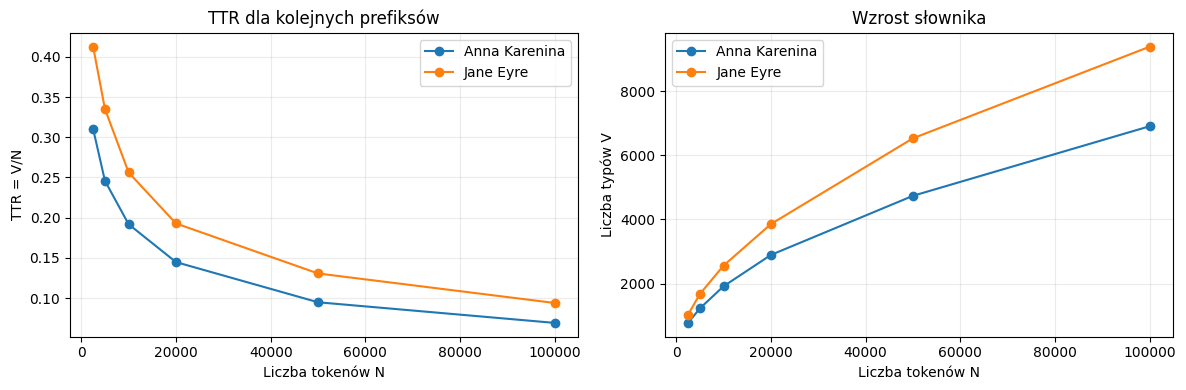

,korpus,N,V,TTR
0,Anna Karenina,2500,776,0.3104
1,Anna Karenina,5000,1229,0.2458
2,Anna Karenina,10000,1918,0.1918
3,Anna Karenina,20000,2894,0.1447
4,Anna Karenina,50000,4736,0.0947
5,Anna Karenina,100000,6904,0.0690
6,Jane Eyre,2500,1032,0.4128
7,Jane Eyre,5000,1676,0.3352
8,Jane Eyre,10000,2562,0.2562
9,Jane Eyre,20000,3856,0.1928


,a,beta,R2_log
korpus,,,
Anna Karenina,2.0866,0.5898,0.9979
Jane Eyre,2.3331,0.5953,0.9981


In [7]:
thresholds = [2500, 5000, 10000, 20000, 50000, 100000]
growth_rows = []
heaps_rows = []
for name, tokens in lower_words.items():
    for size in thresholds:
        if size <= len(tokens):
            vocabulary_size = len(set(tokens[:size]))
            growth_rows.append({"korpus": name, "N": size, "V": vocabulary_size, "TTR": vocabulary_size / size})
growth = pd.DataFrame(growth_rows)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, group in growth.groupby("korpus", sort=False):
    beta, intercept = np.polyfit(np.log(group["N"]), np.log(group["V"]), 1)
    predicted_log = intercept + beta * np.log(group["N"])
    residual = np.sum((np.log(group["V"]) - predicted_log) ** 2)
    total = np.sum((np.log(group["V"]) - np.log(group["V"]).mean()) ** 2)
    heaps_rows.append({"korpus": name, "a": intercept, "beta": beta, "R2_log": 1 - residual / total})
    axes[0].plot(group["N"], group["TTR"], "o-", label=name)
    axes[1].plot(group["N"], group["V"], "o-", label=name)
axes[0].set(xlabel="Liczba tokenów N", ylabel="TTR = V/N", title="TTR dla kolejnych prefiksów")
axes[1].set(xlabel="Liczba tokenów N", ylabel="Liczba typów V", title="Wzrost słownika")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()
heaps = pd.DataFrame(heaps_rows).set_index("korpus")
display(growth.round(4))
display(heaps.round(4))


Bezpośrednie porównanie TTR całych książek może być mylące, ponieważ wraz ze wzrostem liczby tokenów przybywa powtórzeń już zaobserwowanych typów. Dłuższy tekst może więc mieć niższy TTR nawet przy podobnym zróżnicowaniu słownictwa. W obu korpusach porównujemy te same długości prefiksów i identyczne zasady tokenizacji, co ogranicza ten problem. Prefiksy są jednak zagnieżdżone i obejmują różne treści, dlatego nie stanowią niezależnych próbek. Oszacowane β opisuje tempo wzrostu słownika w wybranym zakresie i nie jest stałą cechą autora ani formalnym testem prawa Heapsa.


## 7. N-gramy i kolejność operacji

Dla obu korpusów przygotuj dwie reprezentacje:

A. małe litery, tokeny słowne, słowa stop pozostawione,  
B. małe litery, słowa stop usunięte, negacja zachowana.

Dla obu wariantów pokaż 15 najczęstszych bigramów. Dla wariantu B pokaż dodatkowo 10 najczęstszych trigramów.

Wskaż co najmniej dwa przykłady bigramów z wariantu B, w których sąsiedztwo powstało dopiero po usunięciu słowa stop. Wyjaśnij, jak zmienia to interpretację n-gramu.

In [8]:
ngram_counts = {}
artificial_examples = []
for name, tokenized_sentences in sentence_tokens.items():
    counts_a = Counter()
    counts_b = Counter()
    counts_tri_b = Counter()
    found = set()
    for sentence_number, sentence in enumerate(tokenized_sentences, start=1):
        words_a = [t.lower() for t in sentence if t.isalpha()]
        lexical = lexical_with_negation(sentence)
        retained = [(i, t) for i, t in enumerate(lexical) if t not in stopwords_without_negation]
        words_b = [t for _, t in retained]
        counts_a.update(ngrams(words_a, 2))
        counts_b.update(ngrams(words_b, 2))
        counts_tri_b.update(ngrams(words_b, 3))
        # Zachowane indeksy pozwalają udowodnić usunięcie słów pomiędzy tokenami.
        for (left, t1), (right, t2) in zip(retained, retained[1:]):
            removed = lexical[left + 1:right]
            if (sentence_number > 20 and removed and all(t in stopwords_without_negation for t in removed)
                    and (t1, t2) not in found and len(found) < 3):
                found.add((t1, t2))
                artificial_examples.append({"korpus": name, "bigram_B": f"{t1} {t2}",
                    "przed_usunięciem_stopwords": " ".join(lexical[left:right + 1]),
                    "usunięte_słowa": " ".join(removed)})
    ngram_counts[name] = {"A_bigram": counts_a, "B_bigram": counts_b, "B_trigram": counts_tri_b}
    for variant, counts in ngram_counts[name].items():
        limit = 10 if variant == "B_trigram" else 15
        print(name, variant)
        display(pd.DataFrame([{"n-gram": " ".join(parts), "liczba": count}
                              for parts, count in counts.most_common(limit)]))
artificial_adjacencies = pd.DataFrame(artificial_examples)
assert artificial_adjacencies.groupby("korpus").size().ge(2).all()
print("Przykłady sąsiedztwa utworzonego przez usunięcie słów stop:")
display(artificial_adjacencies)


Anna Karenina A_bigram


,n-gram,liczba
0,of the,1913
1,in the,1608
2,he had,1007
3,to the,990
4,he was,884
5,at the,883
6,and the,727
7,it was,675
8,on the,647
9,did not,643


Anna Karenina B_bigram


,n-gram,liczba
0,alexey alexandrovitch,570
1,stepan arkadyevitch,547
2,could not,532
3,sergey ivanovitch,290
4,ca not,259
5,not know,207
6,darya alexandrovna,204
7,said levin,175
8,would not,173
9,wo not,144


Anna Karenina B_trigram


...

,n-gram,liczba
0,could not,171
1,would not,80
2,miss temple,61
3,miss ingram,54
4,miss eyre,43
5,jane eyre,37
6,no one,34
7,no doubt,34
8,not know,32
9,not like,31


Jane Eyre B_trigram


,n-gram,liczba
0,could not tell,10
1,could not bear,9
2,could not help,6
3,right hand left,5
4,said could not,5
5,sir george lynn,5
6,could not forget,5
7,twenty thousand pounds,5
8,miss eyre not,4
9,poor orphan child,4


Przykłady sąsiedztwa utworzonego przez usunięcie słów stop:


,korpus,bigram_B,przed_usunięciem_stopwords,usunięte_słowa
0,Anna Karenina,oo muttered,oo he muttered,he
1,Anna Karenina,everything happened,everything that had happened,that had
2,Anna Karenina,detail quarrel,detail of his quarrel,of his
3,Jane Eyre,satirist vanity,satirist of vanity,of
4,Jane Eyre,admired high,admired in high,in
5,Jane Eyre,tell think,tell but i think,but i


N-gramy tworzymy osobno w każdym zdaniu; nie łączymy granic zdań. Tabela przykładów pokazuje rzeczywiste wystąpienia, w których między zachowanymi słowami stały słowa stop. Bigram B opisuje więc sąsiedztwo w przefiltrowanej reprezentacji, a niekoniecznie frazę występującą dosłownie w tekście. Już samo usuwanie interpunkcji lub innych tokenów niesłownych może tworzyć nowe sąsiedztwa także w A; porównywane reprezentacje wymagają jawnego wskazania kolejności operacji.


## 8. Porównanie na równych fragmentach tekstu

Podziel każdy korpus na kolejne niepokrywające się fragmenty po 5 000 tokenów słownych po `lower()`. Odrzuć ostatni niepełny fragment.

Dla każdego fragmentu oblicz:

- TTR,
- średnią długość tokenu,
- udział słów stop,
- liczbę negacji na 1 000 tokenów.

Utwórz tabelę, w której jeden wiersz odpowiada jednemu fragmentowi, a następnie porównaj rozkłady miar między książkami za pomocą statystyk opisowych i co najmniej jednego wykresu.

Fragmenty jednej książki nie są niezależną próbą losową. Traktuj analizę jako opis zmienności wewnątrz korpusu, a nie jako podstawę do formalnego wnioskowania o populacji autorów.

Anna Karenina: 68 pełnych fragmentów; odrzucono 4695 tokenów.
Jane Eyre: 35 pełnych fragmentów; odrzucono 4837 tokenów.


,korpus,fragment,pierwszy_token,ostatni_token,TTR,średnia_długość_tokenu,udział_słów_stop,negacje_na_1000
0,Anna Karenina,1,1,5000,0.2458,4.3250,0.5402,14.8
1,Anna Karenina,2,5001,10000,0.2412,4.3770,0.5440,15.2
2,Anna Karenina,3,10001,15000,0.2534,4.2986,0.5420,16.4
3,Anna Karenina,4,15001,20000,0.2230,4.2444,0.5544,23.8
4,Anna Karenina,5,20001,25000,0.2342,4.2944,0.5426,19.6
5,Anna Karenina,6,25001,30000,0.2152,4.2148,0.5502,18.8
6,Anna Karenina,7,30001,35000,0.2364,4.2852,0.5356,18.4
7,Anna Karenina,8,35001,40000,0.2398,4.2832,0.5464,14.8
8,Anna Karenina,9,40001,45000,0.2340,4.2054,0.5622,13.0
9,Anna Karenina,10,45001,50000,0.2570,4.3772,0.5362,13.2


Statystyki opisowe fragmentów:


korpus                        Anna Karenina  Jane Eyre
TTR                    count        68.0000    35.0000
                       mean          0.2388     0.2903
                       std           0.0116     0.0185
                       min           0.2064     0.2538
                       25%           0.2339     0.2763
                       50%           0.2388     0.2866
                       75%           0.2456     0.3023
                       max           0.2638     0.3352
średnia_długość_tokenu count        68.0000    35.0000
                       mean          4.2939     4.1642
                       std           0.0842     0.1141
                       min           4.0196     3.9508
                       25%           4.2496     4.0988
                       50%           4.2856     4.1646
                       75%           4.3531     4.2558
                       max           4.5178     4.3862
udział_słów_stop       count        68.0000    35.0000
                       mean          0.5476     0.5443
                       std           0.0136     0.0157
                       min           0.5142     0.5148
                       25%           0.5376     0.5336
                       50%           0.5461     0.5444
                       75%           0.5582     0.5554
                       max           0.5810     0.5798
negacje_na_1000        count        68.0000    35.0000
                       mean         17.7471    15.0743
                       std           3.2092     2.7603
                       min          11.4000     9.2000
                       25%          15.1500    13.4000
                       50%          18.2000    14.8000
                       75%          20.1000    16.4000
                       max          23.8000    22.6000

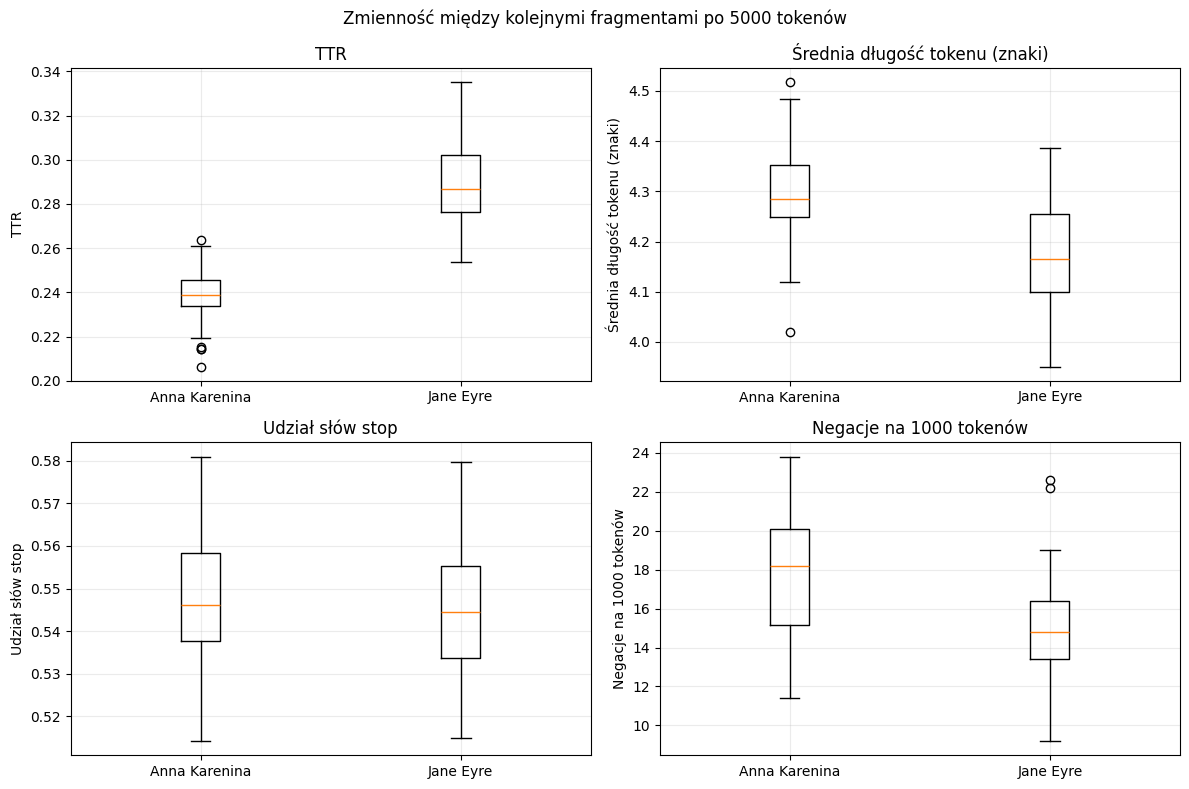

In [9]:
fragment_rows = []
fragment_size = 5000
for name, tokens in lower_words.items():
    # Granice fragmentów wynikają wyłącznie z tokenów isalpha() po lower().
    # Osobno przypisujemy n't do poprzedzającego tokenu słownego (np. do w don't).
    negation_counts = np.zeros(len(tokens), dtype=int)
    word_index = -1
    for token in all_tokens[name]:
        token = token.lower()
        if token.isalpha():
            word_index += 1
            negation_counts[word_index] += int(token in negations)
        elif token == "n't" and word_index >= 0:
            negation_counts[word_index] += 1
    assert word_index + 1 == len(tokens)
    assert negation_counts.sum() == sum(t in negations for t in lexical_with_negation(all_tokens[name]))
    for start in range(0, len(tokens) - fragment_size + 1, fragment_size):
        chunk = tokens[start:start + fragment_size]
        fragment_rows.append({
            "korpus": name, "fragment": start // fragment_size + 1,
            "pierwszy_token": start + 1, "ostatni_token": start + fragment_size,
            "TTR": len(set(chunk)) / fragment_size,
            "średnia_długość_tokenu": np.mean([len(t) for t in chunk]),
            "udział_słów_stop": sum(t in english_stopwords for t in chunk) / fragment_size,
            "negacje_na_1000": negation_counts[start:start + fragment_size].sum() / fragment_size * 1000,
        })
    print(f"{name}: {len(tokens) // fragment_size} pełnych fragmentów; odrzucono {len(tokens) % fragment_size} tokenów.")
fragments = pd.DataFrame(fragment_rows)
metrics = ["TTR", "średnia_długość_tokenu", "udział_słów_stop", "negacje_na_1000"]
with pd.option_context("display.max_rows", None):
    display(fragments.round(4))
fragment_description = fragments.groupby("korpus")[metrics].describe()
print("Statystyki opisowe fragmentów:")
display(fragment_description.T.round(4))
metric_labels = {"TTR": "TTR", "średnia_długość_tokenu": "Średnia długość tokenu (znaki)",
                 "udział_słów_stop": "Udział słów stop", "negacje_na_1000": "Negacje na 1000 tokenów"}
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, metric in zip(axes.flat, metrics):
    groups = [fragments.loc[fragments["korpus"] == name, metric] for name in corpora]
    ax.boxplot(groups)
    ax.set_xticks(range(1, len(corpora) + 1), list(corpora))
    ax.set(title=metric_labels[metric], ylabel=metric_labels[metric])
plt.suptitle("Zmienność między kolejnymi fragmentami po 5000 tokenów")
plt.tight_layout()
plt.show()
assert all(len(fragments[fragments["korpus"] == name]) == len(tokens) // fragment_size
           for name, tokens in lower_words.items())


Udział słów stop liczymy względem pełnej listy NLTK (łącznie z `no`, `nor`, `not`), ponieważ tutaj mierzymy ich udział, a nie usuwamy ich z tekstu. Licznik negacji obejmuje `no`, `nor`, `not` i znormalizowane `n't`. Token `n't` nie wchodzi do 5000 słów wyznaczających granice fragmentu; jego wystąpienie przypisujemy do poprzedzającego słowa, aby nie zgubić kontrakcji ani nie zmienić długości porównywanych fragmentów.

Wykresy i statystyki opisują zmienność wewnątrz tych dwóch książek. Kolejne fragmenty są zależne narracyjnie, a próbki mają różne liczebności; nie przeprowadzamy testu różnic między populacjami autorów.


W badanych fragmentach *Jane Eyre* ma wyższy typowy TTR, natomiast *Anna Karenina* większą średnią długość tokenu i częstsze negacje. Rozkłady udziału słów stop silnie się pokrywają. Są to obserwacje dotyczące tych korpusów i przyjętego przetwarzania, bez interpretacji przyczynowej.


## 9. Synteza

Zbuduj końcową tabelę zawierającą wybrane miary z poprzednich części.

Napisz krótkie podsumowanie, w którym wyraźnie rozdzielisz:

1. obserwacje wynikające bezpośrednio z obliczeń,
2. możliwe interpretacje,
3. ograniczenia porównania.

Uwzględnij co najmniej:

- różną długość tekstów,
- wpływ tokenizacji i normalizacji,
- zależność miar słownikowych od długości próbki,
- fakt, że *Anna Karenina* jest analizowana w przekładzie.

In [10]:
final_rows = []
for name, tokens in lower_words.items():
    group = fragments[fragments["korpus"] == name]
    morphology = morphology_summary[morphology_summary["korpus"] == name].set_index("reprezentacja")
    at_20000 = growth[(growth["korpus"] == name) & (growth["N"] == 20000)].iloc[0]
    final_rows.append({
        "korpus": name,
        "tokeny_słowne": len(tokens),
        "typy_lower": len(set(tokens)),
        "TTR_całości": len(set(tokens)) / len(tokens),
        "średnia_słów_w_zdaniu": summary.loc[name, "średnia_słów_w_zdaniu"],
        "TTR_pierwszych_20000": at_20000["TTR"],
        "beta_Heapsa": heaps.loc[name, "beta"],
        "redukcja_stem_%": morphology.loc["stem", "redukcja_%_względem_lower"],
        "redukcja_lemma_%": morphology.loc["lemma", "redukcja_%_względem_lower"],
        "pełne_fragmenty": len(group),
        "średni_TTR_fragmentów": group["TTR"].mean(),
        "średnia_długość_tokenu_fragmentów": group["średnia_długość_tokenu"].mean(),
        "średni_udział_stopwords_fragmentów": group["udział_słów_stop"].mean(),
        "średnie_negacje_na_1000_fragmentów": group["negacje_na_1000"].mean(),
    })
final_comparison = pd.DataFrame(final_rows).set_index("korpus")
display(final_comparison.T.round(4))

# Spójność obliczeń między częściami zadania.
for name in corpora:
    assert sum(frequency_counts[name].values()) == summary.loc[name, "tokeny_słowne"]
    assert variants[name]["B"] == lower_words[name]
    assert len(representations[name]["lower"]) == 20000
assert fragments["TTR"].between(0, 1).all()
assert fragments["udział_słów_stop"].between(0, 1).all()
print("Kontrole spójności zakończone poprawnie.")


korpus,Anna Karenina,Jane Eyre
tokeny_słowne,344695.0000,179837.0000
typy_lower,12277.0000,12124.0000
TTR_całości,0.0356,0.0674
średnia_słów_w_zdaniu,20.4530,26.0709
TTR_pierwszych_20000,0.1447,0.1928
beta_Heapsa,0.5898,0.5953
redukcja_stem_%,20.5598,20.9544
redukcja_lemma_%,16.2405,16.3122
pełne_fragmenty,68.0000,35.0000
średni_TTR_fragmentów,0.2388,0.2903


Kontrole spójności zakończone poprawnie.


Podsumowanie:

**Obserwacje z obliczeń.** *Anna Karenina* zawiera 344 695 tokenów słownych, a *Jane Eyre* 179 837 — pierwszy korpus jest 1,92 razy dłuższy. TTR całych książek wynosi odpowiednio 0,0356 i 0,0674, natomiast dla pierwszych 20 000 tokenów: 0,1447 i 0,1928. Średni TTR fragmentów po 5000 słów to 0,2388 oraz 0,2903; porównujemy 68 i 35 pełnych fragmentów. Oszacowania β wynoszą 0,590 oraz 0,595. Średnie częstości negacji we fragmentach to odpowiednio 17,75 i 15,07 na 1000 słów.

**Możliwe interpretacje.** Różnice miar mogą odzwierciedlać udział dialogów, sposób narracji, tematykę i powtarzalność imion lub innych nazw. Wyższy TTR nie oznacza automatycznie bogatszego stylu, a liczba słów negujących nie jest miarą sentymentu.

**Ograniczenia.** Książki mają różne długości, a TTR zależy od długości próbki. Tokenizacja, wybór `isalpha()`, małe litery, stopwords i sprowadzanie form zmieniają reprezentację oraz jej interpretację. Zawartość między znacznikami Gutenberga obejmuje również elementy wydania; prefiksy mogą być szczególnie wrażliwe na przedmowę i spis treści. Fragmenty nie są niezależnymi próbkami losowymi, a *Anna Karenina* jest analizowana w angielskim przekładzie Constance Garnett, więc obserwowanych różnic nie przypisujemy wyłącznie autorom.
